Notebook to evaluate the ranking of the retrievers for all datasets in one run

In [1]:
import ir_datasets
DATASETS=["beir/trec-covid","beir/arguana","beir/scifact/test","beir/scifact/train","beir/scidocs",
          "beir/nfcorpus/train","beir/nfcorpus/test","beir/nfcorpus/dev","beir/fiqa/train",
          "beir/fiqa/test","beir/fiqa/dev","beir/cqadupstack/android","beir/cqadupstack/english",
          "beir/cqadupstack/gaming","beir/cqadupstack/gis","beir/cqadupstack/mathematica",
          "beir/cqadupstack/physics","beir/cqadupstack/programmers","beir/cqadupstack/stats",
          "beir/cqadupstack/tex","beir/cqadupstack/unix","beir/cqadupstack/webmasters",
          "beir/cqadupstack/wordpress"]

# Helper functions

## Sparse

In [2]:
import numpy as np
from collections import defaultdict
import math

# -------------------------------
# 1️⃣ Functions for sparse retriever
# -------------------------------
def mrr_at_k_sparse(run, qrels, k=10):
    mrrs = []
    for qid, ranked in run.items():
        relset = qrels.get(qid, {})
        rr = 0.0
        for i, (docid, _) in enumerate(ranked[:k], start=1):
            if relset.get(docid, 0) > 0:
                rr = 1.0 / i
                break
        mrrs.append(rr)
    return float(np.mean(mrrs)) if mrrs else 0.0


def ndcg_at_k_sparse(run, qrels, k=10):
    def dcg(rels):
        return sum((rel / math.log2(i + 2)) for i, rel in enumerate(rels))

    vals = []
    for qid, ranked in run.items():
        rels = [1 if qrels.get(qid, {}).get(docid, 0) > 0 else 0 for docid, _ in ranked[:k]]
        idcg = dcg(sorted(rels, reverse=True))
        v = (dcg(rels) / idcg) if idcg > 0 else 0.0
        vals.append(v)
    return float(np.mean(vals)) if vals else 0.0
    
def precision_at_k_sparse(run, qrels, k=10):
    precisions = []
    for qid, ranked in run.items():
        rels = [1 if qrels.get(qid, {}).get(docid, 0) > 0 else 0 for docid, _ in ranked[:k]]
        precisions.append(sum(rels) / len(rels) if rels else 0)
    return float(np.mean(precisions)) if precisions else 0.0


def recall_at_k_sparse(run, qrels, k=100):
    recalls = []
    for qid, ranked in run.items():
        relset = qrels.get(qid, {})
        total_rel = len([d for d in relset if relset[d] > 0])
        if total_rel == 0:
            continue
        rels = [1 if relset.get(docid, 0) > 0 else 0 for docid, _ in ranked[:k]]
        recalls.append(sum(rels) / total_rel)
    return float(np.mean(recalls)) if recalls else 0.0


def map_at_k_sparse(run, qrels, k=1000):
    ap_scores = []
    for qid, ranked in run.items():
        relset = qrels.get(qid, {})
        num_rel = 0
        score = 0.0
        for i, (docid, _) in enumerate(ranked[:k], start=1):
            if relset.get(docid, 0) > 0:
                num_rel += 1
                score += num_rel / i
        if num_rel > 0:
            ap_scores.append(score / num_rel)
    return float(np.mean(ap_scores)) if ap_scores else 0.0



# -------------------------------
# 2️⃣ Load run file (.trec)
# -------------------------------
def load_sparse_run(file_path):
    run_records = []
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 6:
                continue  # skip malformed lines
            qid, _, docid, _, score, _ = parts
            run_records.append((qid, docid, float(score)))
    return run_records


# -------------------------------
# 3️⃣ Convert to grouped format
# -------------------------------
def group_run_records(run_records):
    run_per_q = defaultdict(list)
    for qid, docid, score in run_records:
        run_per_q[qid].append((docid, score))
    for qid in run_per_q:
        run_per_q[qid].sort(key=lambda x: x[1], reverse=True)
    return run_per_q

# -------------------------------
# 📊 Unified Evaluation Function
# -------------------------------
def evaluate_sparse_metrics(qrels, DATASET_NAME):
    RUN_PATH = f"runs/run_bm25_{DATASET_NAME.replace('/', '_')}.trec"
    run_records = load_sparse_run(RUN_PATH)
    run_per_q = group_run_records(run_records)

    metrics = {
        "nDCG@10": ndcg_at_k_sparse(run_per_q, qrels, k=10),
        "MRR@10": mrr_at_k_sparse(run_per_q, qrels, k=10),
        "Precision@10": precision_at_k_sparse(run_per_q, qrels, k=10),
        "Recall@100": recall_at_k_sparse(run_per_q, qrels, k=100),
        "MAP@1000": map_at_k_sparse(run_per_q, qrels, k=1000),
    }

    return metrics



## Dense

In [6]:
import os
import math
import numpy as np
from collections import defaultdict


# -------------------------------
# 📥 Load Dense Retriever Run (.trec)
# -------------------------------
def load_dense_run(file_path):
    run_per_q = defaultdict(list)
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 6:
                continue
            qid, _, docid, rank, score, _ = parts
            run_per_q[qid].append((docid, float(score)))
    for qid in run_per_q:
        run_per_q[qid].sort(key=lambda x: x[1], reverse=True)
    return run_per_q


# -------------------------------
# ⚙️ Metric Functions
# -------------------------------
def mrr_at_k_dense(run, qrels, k=10):
    mrrs = []
    for qid, ranked in run.items():
        relset = qrels.get(qid, {})
        rr = 0.0
        for i, (docid, _) in enumerate(ranked[:k], start=1):
            if relset.get(docid, 0) > 0:
                rr = 1.0 / i
                break
        mrrs.append(rr)
    return float(np.mean(mrrs)) if mrrs else 0.0


def ndcg_at_k_dense(run, qrels, k=10):
    def dcg(rels): return sum(rel / math.log2(i + 2) for i, rel in enumerate(rels))
    vals = []
    for qid, ranked in run.items():
        rels = [1 if qrels.get(qid, {}).get(docid, 0) > 0 else 0 for docid, _ in ranked[:k]]
        idcg = dcg(sorted(rels, reverse=True))
        vals.append((dcg(rels) / idcg) if idcg > 0 else 0.0)
    return float(np.mean(vals)) if vals else 0.0


def precision_at_k_dense(run, qrels, k=10):
    vals = []
    for qid, ranked in run.items():
        rels = [1 if qrels.get(qid, {}).get(docid, 0) > 0 else 0 for docid, _ in ranked[:k]]
        vals.append(sum(rels) / len(rels) if rels else 0)
    return float(np.mean(vals)) if vals else 0.0


def recall_at_k_dense(run, qrels, k=100):
    vals = []
    for qid, ranked in run.items():
        relset = qrels.get(qid, {})
        total_rel = len([d for d in relset if relset[d] > 0])
        if total_rel == 0:
            continue
        rels = [1 if relset.get(docid, 0) > 0 else 0 for docid, _ in ranked[:k]]
        vals.append(sum(rels) / total_rel)
    return float(np.mean(vals)) if vals else 0.0


def map_at_k_dense(run, qrels, k=1000):
    ap_scores = []
    for qid, ranked in run.items():
        relset = qrels.get(qid, {})
        num_rel = 0
        score = 0.0
        for i, (docid, _) in enumerate(ranked[:k], start=1):
            if relset.get(docid, 0) > 0:
                num_rel += 1
                score += num_rel / i
        if num_rel > 0:
            ap_scores.append(score / num_rel)
    return float(np.mean(ap_scores)) if ap_scores else 0.0


# -------------------------------
# 🧩 Unified Dense Evaluation
# -------------------------------
def evaluate_dense_metrics(qrels, DATASET_NAME):
    RUN_PATH = f"runs/run_dense_{DATASET_NAME.replace('/', '_')}.trec"
    run_per_q = load_dense_run(RUN_PATH)

    metrics = {
        "nDCG@10": ndcg_at_k_dense(run_per_q, qrels, k=10),
        "MRR@10": mrr_at_k_dense(run_per_q, qrels, k=10),
        "Precision@10": precision_at_k_dense(run_per_q, qrels, k=10),
        "Recall@100": recall_at_k_dense(run_per_q, qrels, k=100),
        "MAP@1000": map_at_k_dense(run_per_q, qrels, k=1000),
    }

    return metrics




## Visualization

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# -------------------------------
# 🧩 1️⃣ Compute dataset metadata
# -------------------------------
def get_dataset_metadata(dataset):
    """Returns number of docs, queries, qrels, and relevance counts."""
    num_docs = sum(1 for _ in dataset.docs_iter())
    num_queries = sum(1 for _ in dataset.queries_iter())
    relevance_counts = Counter()
    num_qrels = 0
    for r in dataset.qrels_iter():
        num_qrels += 1
        relevance_counts[int(r.relevance)] += 1

    # -------------------------------
    # 📘 Print Metadata Summary
    # -------------------------------
    print(f"📚 Dataset: {DATASET_NAME}")
    print(f"  • Documents: {num_docs:,}")
    print(f"  • Queries:   {num_queries:,}")
    print(f"  • Qrels:     {num_qrels:,}")
    print(f"  • Relevance Distribution: {relevance_counts}")
    
    return num_docs, num_queries, num_qrels, dict(relevance_counts)


def plot_results(DATASET_NAME,dataset,qrels):
    num_docs, num_queries, num_qrels, relevance_counts = get_dataset_metadata(dataset)
    bm25_metrics = evaluate_sparse_metrics(qrels, DATASET_NAME)
    dense_metrics = evaluate_dense_metrics(qrels, DATASET_NAME)
    
    hybrid_metrics = {
        "nDCG@10": 0.6551,
        "MRR@10": 0.7610,
        "Precision@10": 0.4782,
        "Recall@100": 0.8320,
        "MAP@1000": 0.5624,
    }
    
    
    # -------------------------------
    # 📈 3️⃣ Bar Chart Comparison
    # -------------------------------
    metrics = list(bm25_metrics.keys())
    systems = ["BM25", "Dense", "Hybrid"]
    values = np.array([
        [bm25_metrics[m] for m in metrics],
        [dense_metrics[m] for m in metrics],
        [hybrid_metrics[m] for m in metrics]
    ])
    
    x = np.arange(len(metrics))
    width = 0.25
    
    fig, ax = plt.subplots(figsize=(9, 5))
    
    for i, sys in enumerate(systems):
        ax.bar(x + (i - 1)*width, values[i], width, label=sys)
    
    ax.set_ylabel('Score')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics, rotation=30)
    ax.legend()
    
    # ✅ Title with dataset name
    ax.set_title(f'IR Metric Comparison Across Retrievers for {DATASET_NAME.upper()} Dataset')
    
    # 📝 Metadata annotation below chart
    metadata_text = (
        f"Documents: {num_docs:,} | Queries: {num_queries:,} | Qrels: {num_qrels:,} | "
        f"Relevance Breakdown: " +
        ", ".join([f"{k}: {v:,}" for k, v in relevance_counts.items()])
    )
    
    plt.figtext(0.5, -0.05, metadata_text, wrap=True,
                horizontalalignment='center', fontsize=9, color='gray')
    
    plt.tight_layout()
    plt.show()


# Execution

Loaded beir/trec-covid
Docs: 171332, Queries: 50
📚 Dataset: beir/trec-covid
  • Documents: 171,332
  • Queries:   50
  • Qrels:     66,336
  • Relevance Distribution: Counter({0: 41661, 2: 14217, 1: 10456, -1: 2})


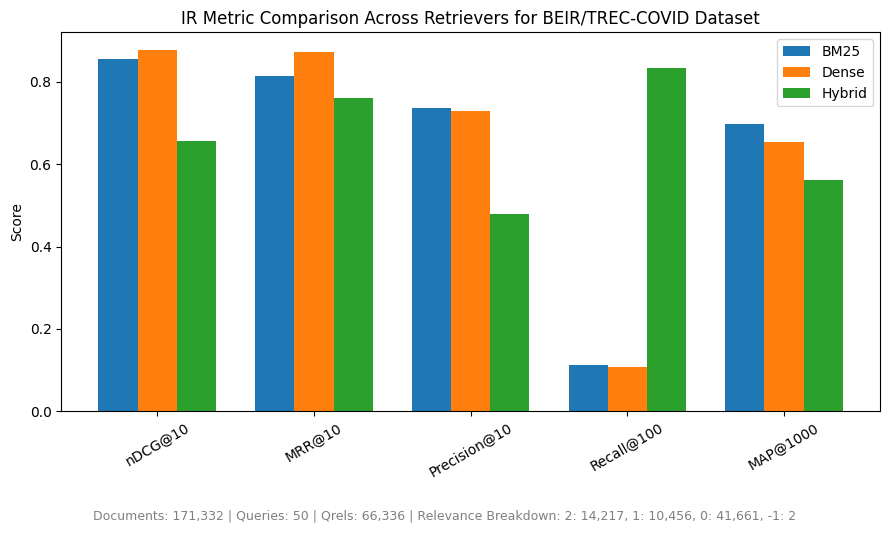

Loaded beir/arguana
Docs: 8674, Queries: 1406
📚 Dataset: beir/arguana
  • Documents: 8,674
  • Queries:   1,406
  • Qrels:     1,406
  • Relevance Distribution: Counter({1: 1406})


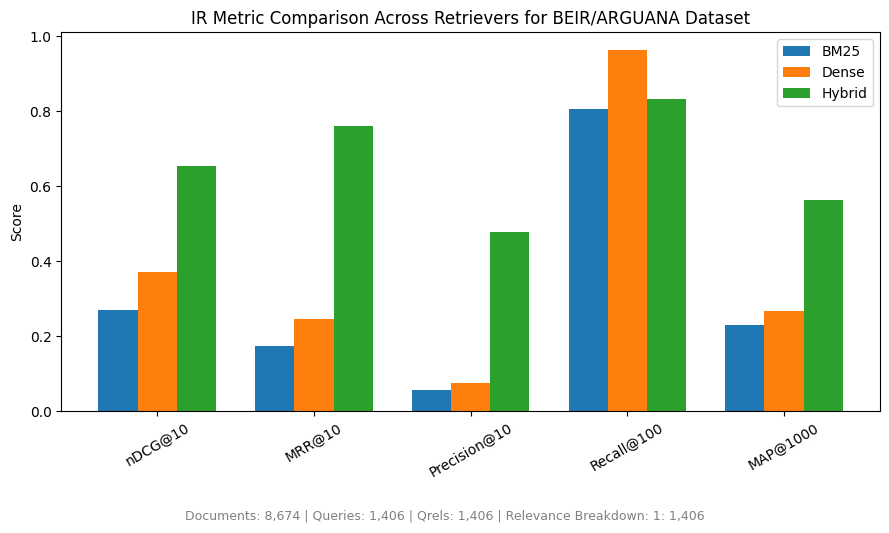

Loaded beir/scifact/test
Docs: 5183, Queries: 300
📚 Dataset: beir/scifact/test
  • Documents: 5,183
  • Queries:   300
  • Qrels:     339
  • Relevance Distribution: Counter({1: 339})


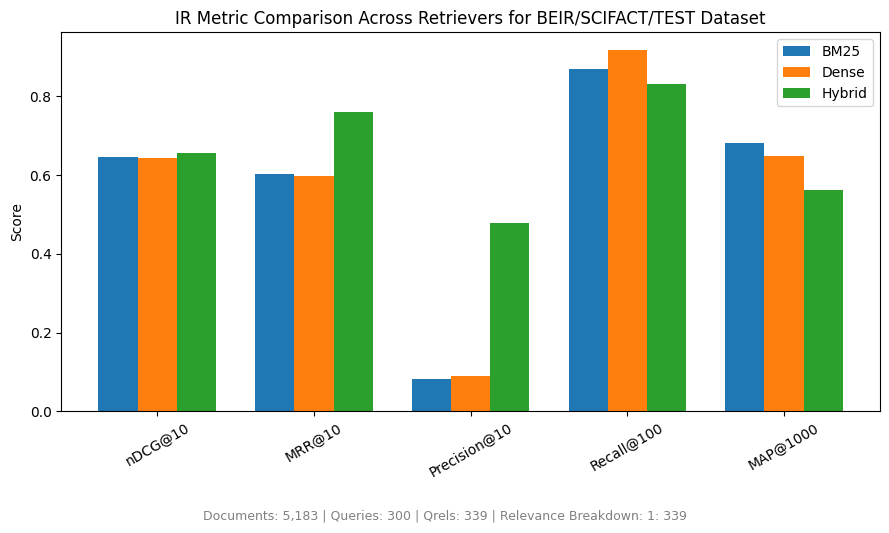

Loaded beir/scifact/train
Docs: 5183, Queries: 809
📚 Dataset: beir/scifact/train
  • Documents: 5,183
  • Queries:   809
  • Qrels:     919
  • Relevance Distribution: Counter({1: 919})


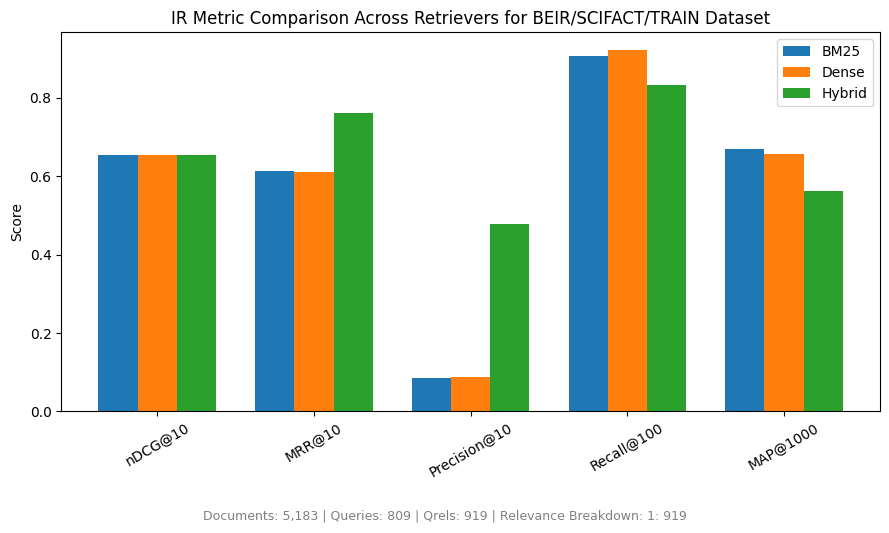

Loaded beir/scidocs
Docs: 25657, Queries: 1000
📚 Dataset: beir/scidocs
  • Documents: 25,657
  • Queries:   1,000
  • Qrels:     29,928
  • Relevance Distribution: Counter({0: 25000, 1: 4928})


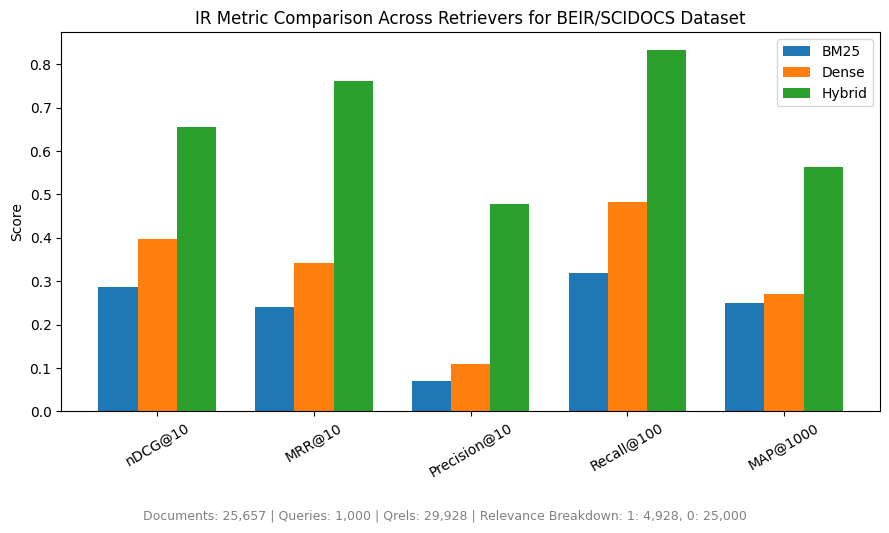

Loaded beir/nfcorpus/train
Docs: 3633, Queries: 2590
📚 Dataset: beir/nfcorpus/train
  • Documents: 3,633
  • Queries:   2,590
  • Qrels:     110,575
  • Relevance Distribution: Counter({1: 110575})


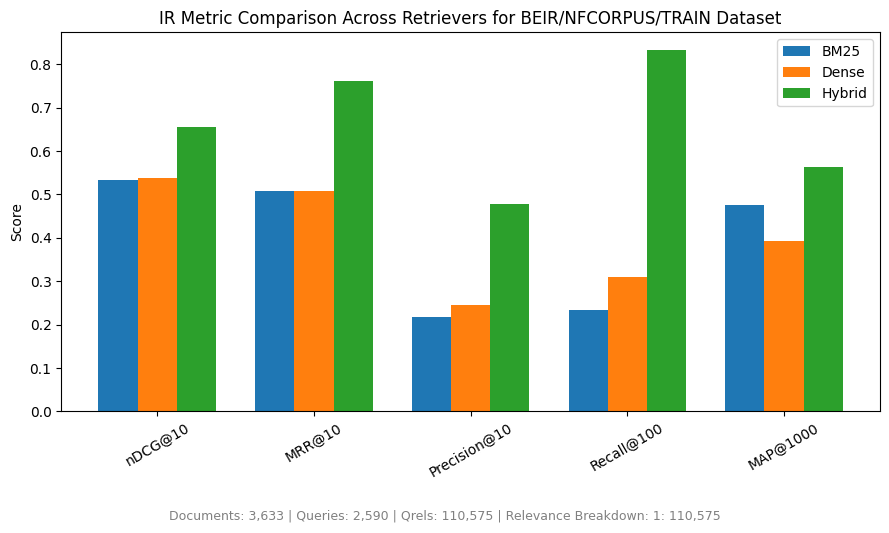

Loaded beir/nfcorpus/test
Docs: 3633, Queries: 323
📚 Dataset: beir/nfcorpus/test
  • Documents: 3,633
  • Queries:   323
  • Qrels:     12,334
  • Relevance Distribution: Counter({1: 11758, 2: 576})


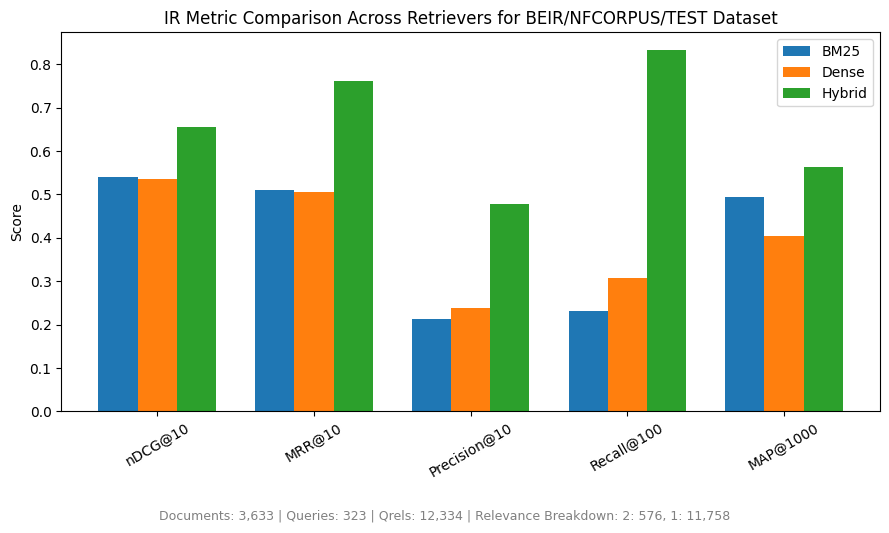

Loaded beir/nfcorpus/dev
Docs: 3633, Queries: 324
📚 Dataset: beir/nfcorpus/dev
  • Documents: 3,633
  • Queries:   324
  • Qrels:     11,385
  • Relevance Distribution: Counter({1: 10864, 2: 521})


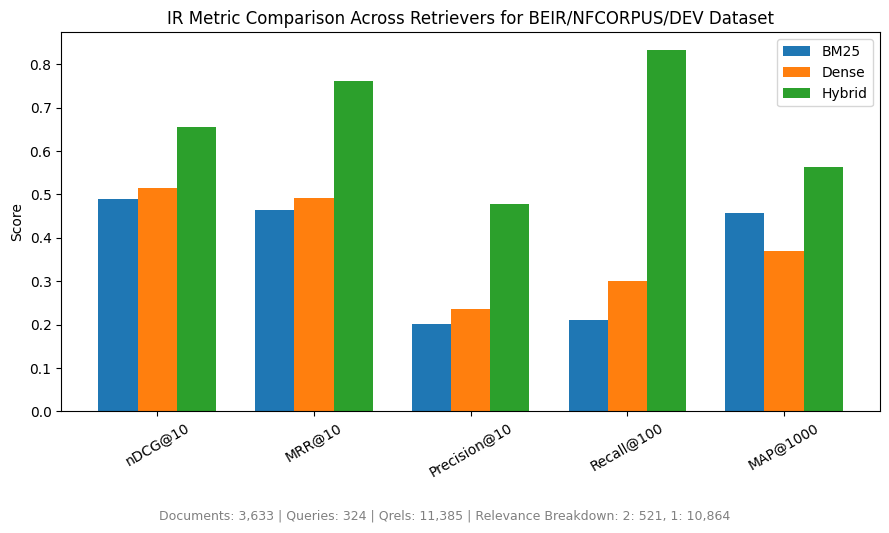

Loaded beir/fiqa/train
Docs: 57638, Queries: 5500
📚 Dataset: beir/fiqa/train
  • Documents: 57,638
  • Queries:   5,500
  • Qrels:     14,166
  • Relevance Distribution: Counter({1: 14166})


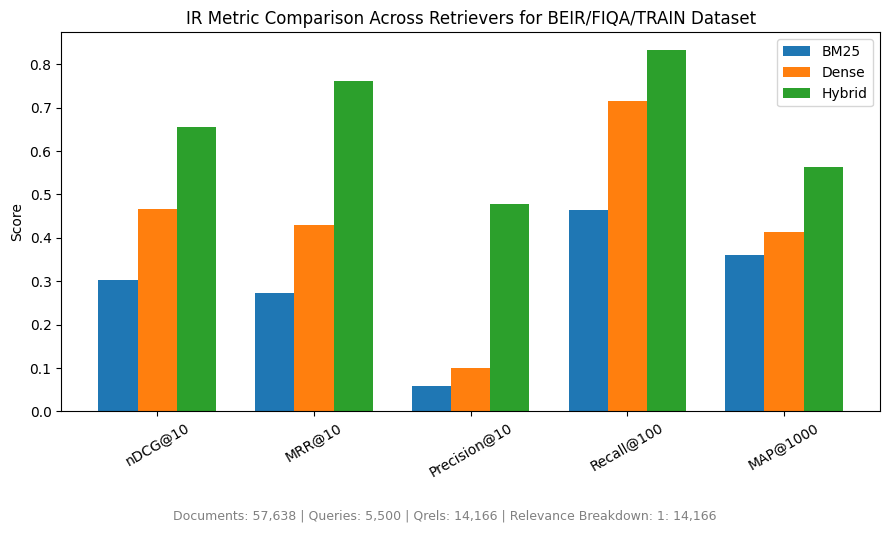

Loaded beir/fiqa/test
Docs: 57638, Queries: 648
📚 Dataset: beir/fiqa/test
  • Documents: 57,638
  • Queries:   648
  • Qrels:     1,706
  • Relevance Distribution: Counter({1: 1706})


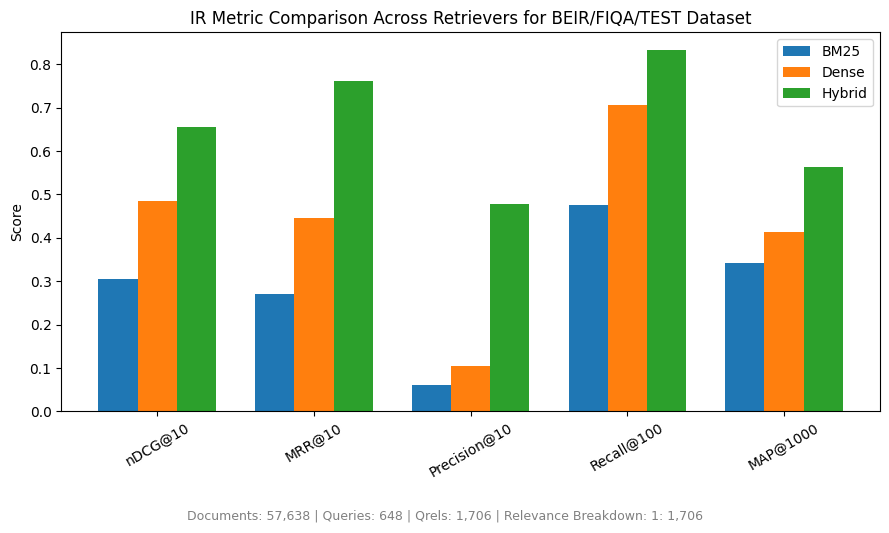

Loaded beir/fiqa/dev
Docs: 57638, Queries: 500
📚 Dataset: beir/fiqa/dev
  • Documents: 57,638
  • Queries:   500
  • Qrels:     1,238
  • Relevance Distribution: Counter({1: 1238})


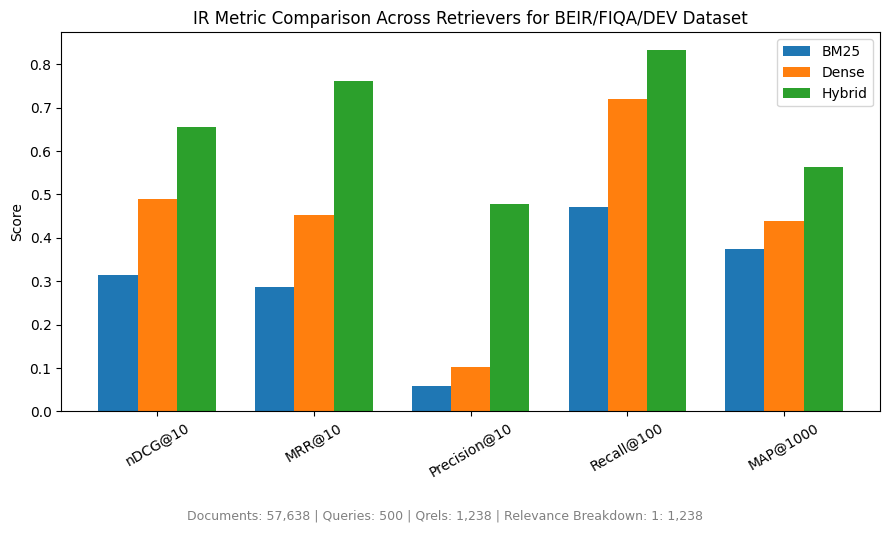

Loaded beir/cqadupstack/android
Docs: 22998, Queries: 699
📚 Dataset: beir/cqadupstack/android
  • Documents: 22,998
  • Queries:   699
  • Qrels:     1,696
  • Relevance Distribution: Counter({1: 1696})


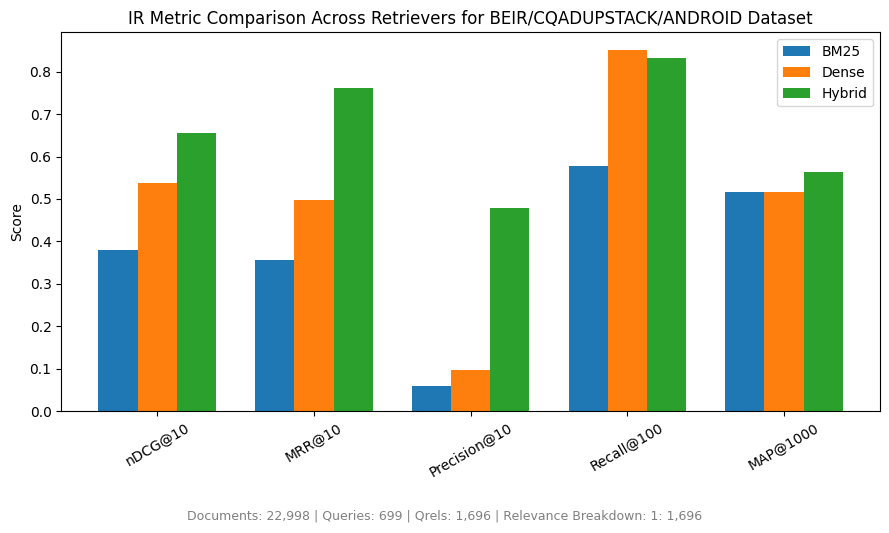

Loaded beir/cqadupstack/english
Docs: 40221, Queries: 1570
📚 Dataset: beir/cqadupstack/english
  • Documents: 40,221
  • Queries:   1,570
  • Qrels:     3,765
  • Relevance Distribution: Counter({1: 3765})


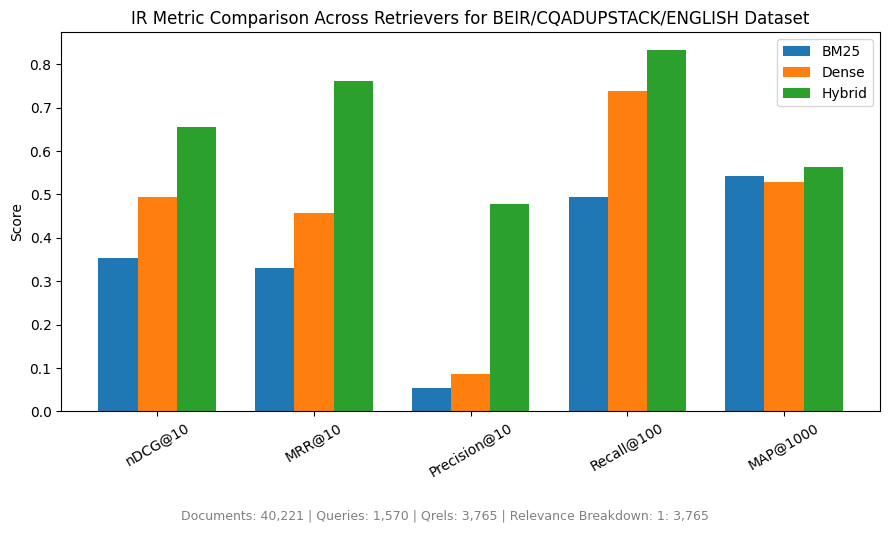

Loaded beir/cqadupstack/gaming
Docs: 45301, Queries: 1595
📚 Dataset: beir/cqadupstack/gaming
  • Documents: 45,301
  • Queries:   1,595
  • Qrels:     2,263
  • Relevance Distribution: Counter({1: 2263})


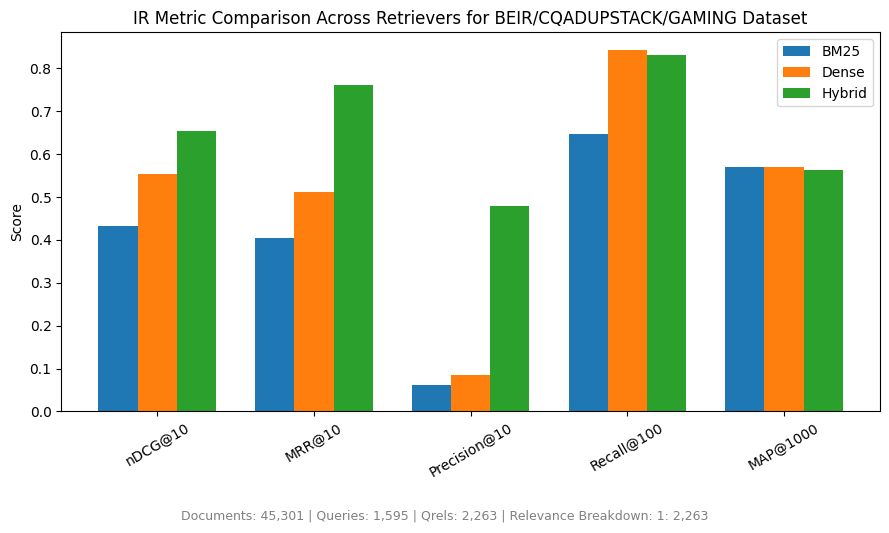

Loaded beir/cqadupstack/gis
Docs: 37637, Queries: 885
📚 Dataset: beir/cqadupstack/gis
  • Documents: 37,637
  • Queries:   885
  • Qrels:     1,114
  • Relevance Distribution: Counter({1: 1114})


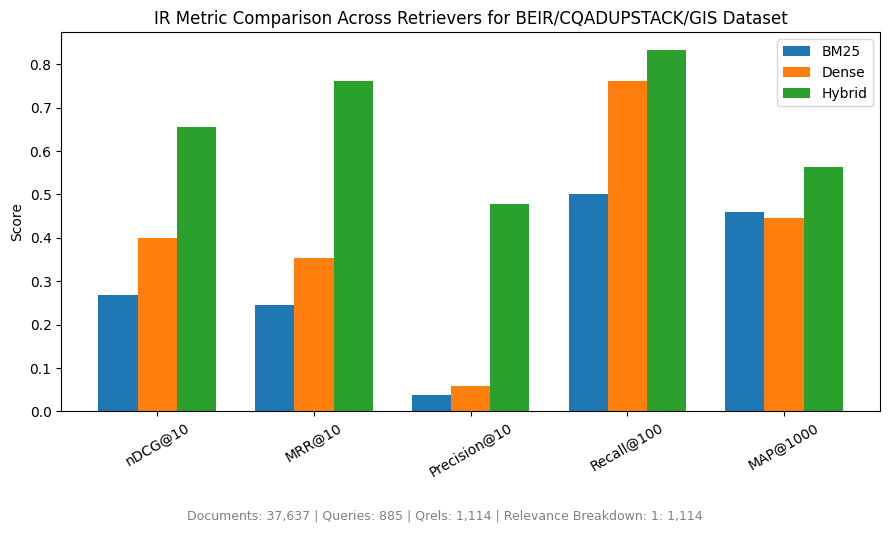

Loaded beir/cqadupstack/mathematica
Docs: 16705, Queries: 804
📚 Dataset: beir/cqadupstack/mathematica
  • Documents: 16,705
  • Queries:   804
  • Qrels:     1,358
  • Relevance Distribution: Counter({1: 1358})


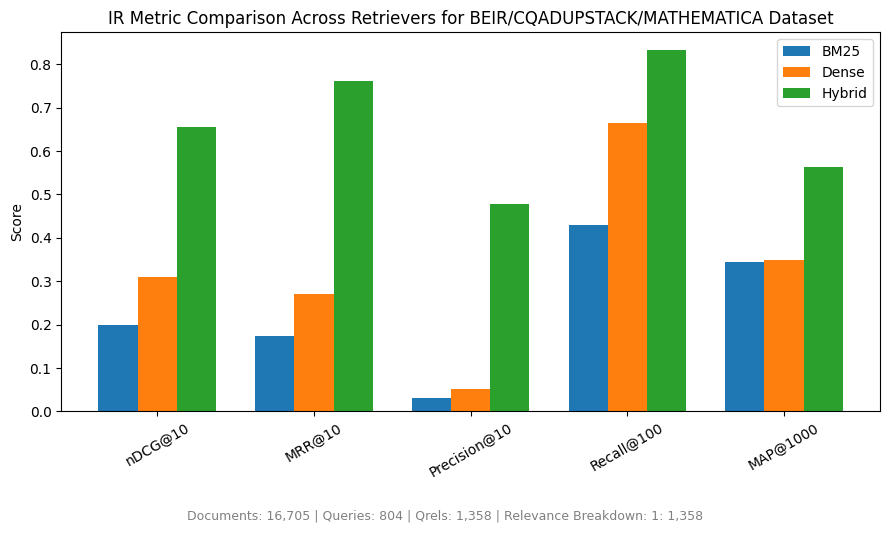

Loaded beir/cqadupstack/physics
Docs: 38316, Queries: 1039
📚 Dataset: beir/cqadupstack/physics
  • Documents: 38,316
  • Queries:   1,039
  • Qrels:     1,933
  • Relevance Distribution: Counter({1: 1933})


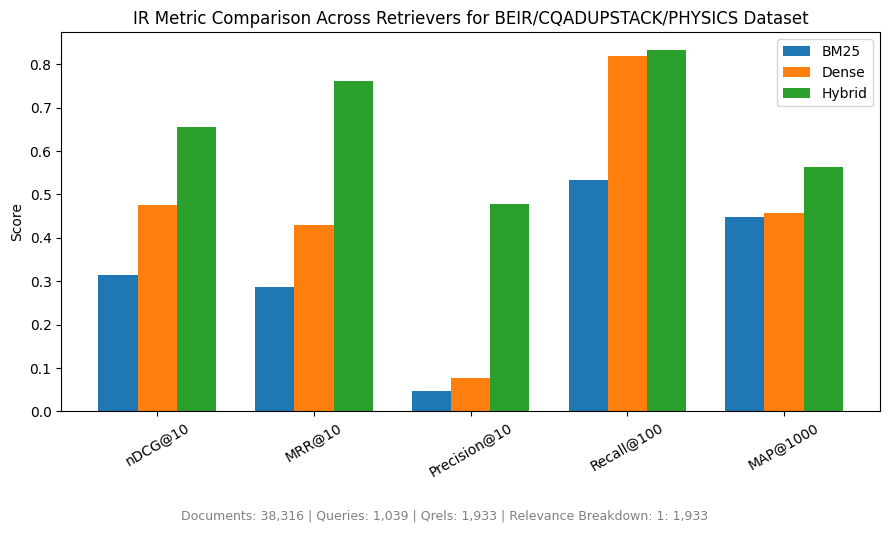

Loaded beir/cqadupstack/programmers
Docs: 32176, Queries: 876
📚 Dataset: beir/cqadupstack/programmers
  • Documents: 32,176
  • Queries:   876
  • Qrels:     1,675
  • Relevance Distribution: Counter({1: 1675})


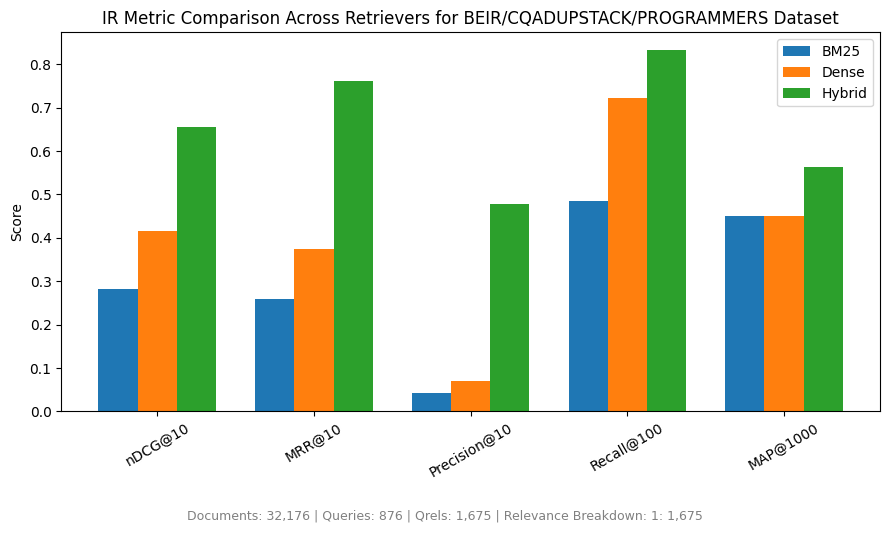

Loaded beir/cqadupstack/stats
Docs: 42269, Queries: 652
📚 Dataset: beir/cqadupstack/stats
  • Documents: 42,269
  • Queries:   652
  • Qrels:     913
  • Relevance Distribution: Counter({1: 913})


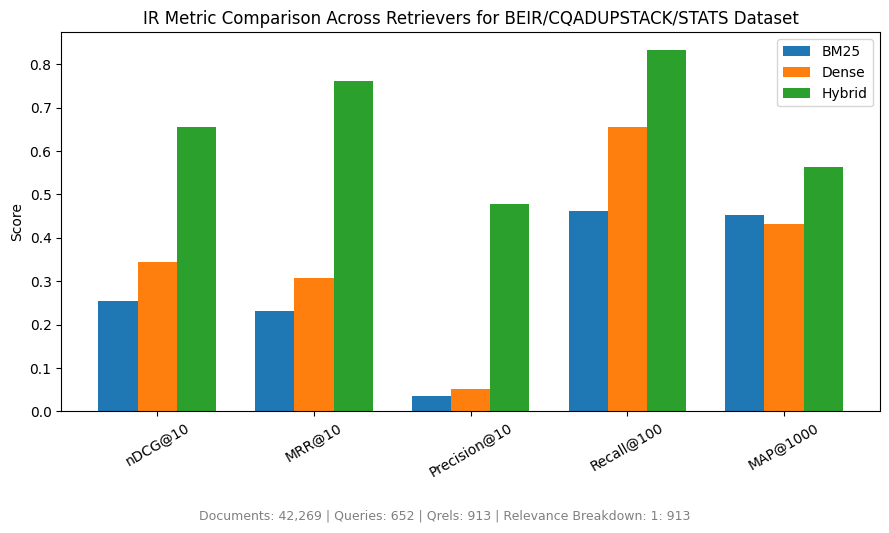

Loaded beir/cqadupstack/tex
Docs: 68184, Queries: 2906
📚 Dataset: beir/cqadupstack/tex
  • Documents: 68,184
  • Queries:   2,906
  • Qrels:     5,154
  • Relevance Distribution: Counter({1: 5154})


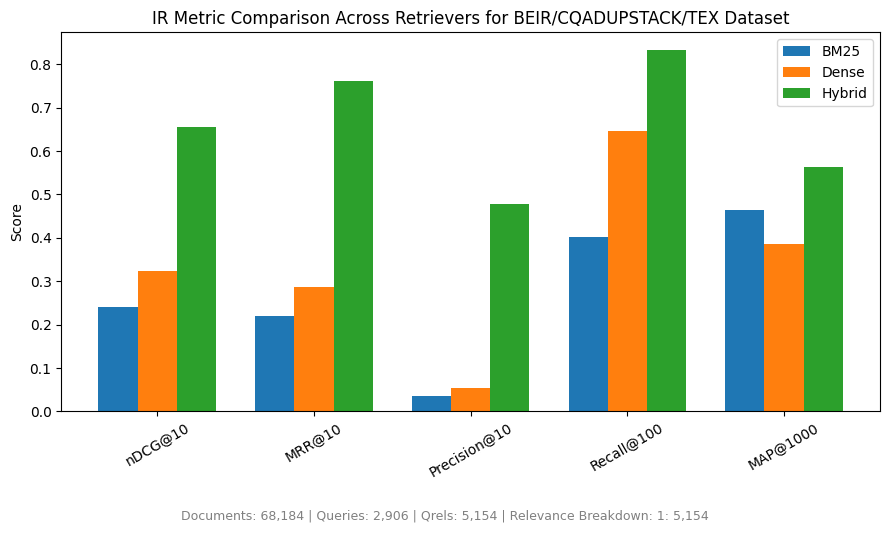

Loaded beir/cqadupstack/unix
Docs: 47382, Queries: 1072


[INFO] [starting] opening zip file
[INFO] [finished] opening zip file s]


📚 Dataset: beir/cqadupstack/unix
  • Documents: 47,382
  • Queries:   1,072
  • Qrels:     1,693
  • Relevance Distribution: Counter({1: 1693})


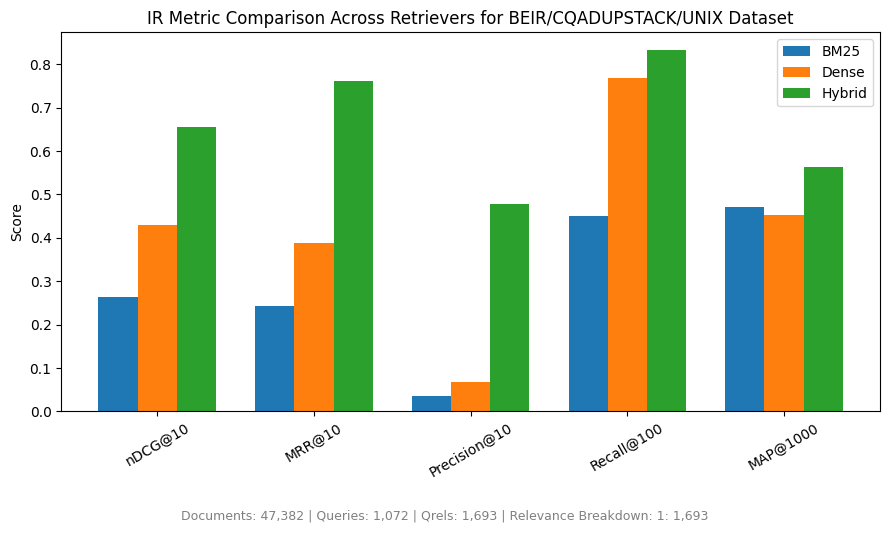

Loaded beir/cqadupstack/webmasters
Docs: 17405, Queries: 506


[INFO] [starting] opening zip file
[INFO] [finished] opening zip file s]


📚 Dataset: beir/cqadupstack/webmasters
  • Documents: 17,405
  • Queries:   506
  • Qrels:     1,395
  • Relevance Distribution: Counter({1: 1395})


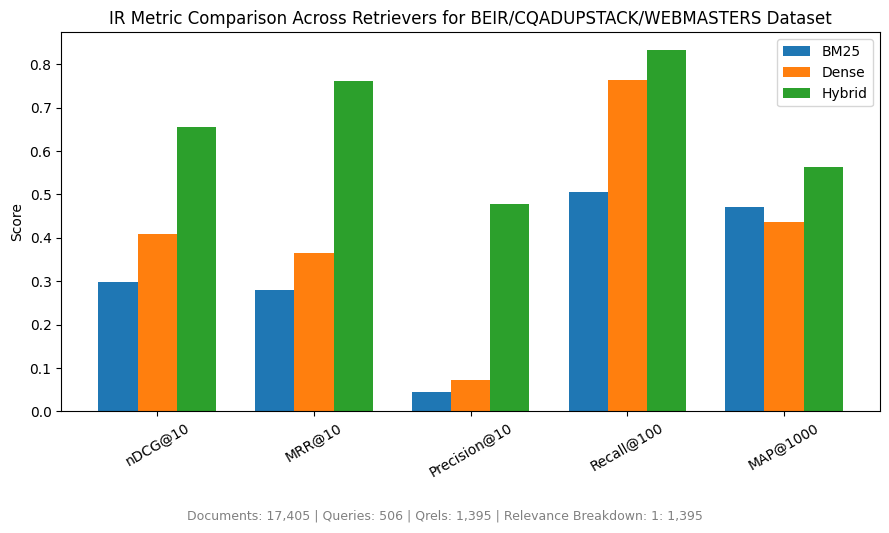

Loaded beir/cqadupstack/wordpress
Docs: 48605, Queries: 541


[INFO] [starting] opening zip file
[INFO] [finished] opening zip file s]


📚 Dataset: beir/cqadupstack/wordpress
  • Documents: 48,605
  • Queries:   541
  • Qrels:     744
  • Relevance Distribution: Counter({1: 744})


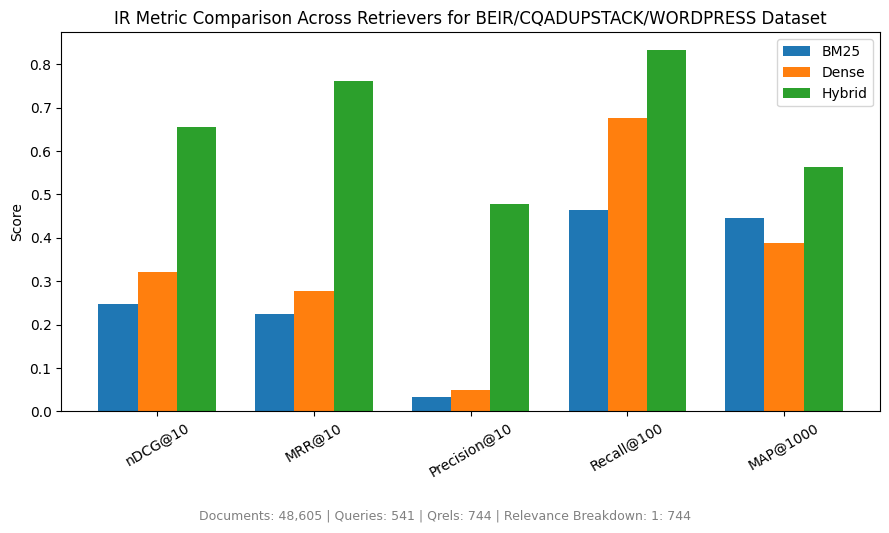

In [7]:
for DATASET_NAME in DATASETS:
    dataset = ir_datasets.load(DATASET_NAME)
    print(f"Loaded {DATASET_NAME}")
    print(f"Docs: {dataset.docs_count()}, Queries: {dataset.queries_count()}")
    qrels = {}
    for r in dataset.qrels_iter():
        qrels.setdefault(str(r.query_id), {})[str(r.doc_id)] = int(r.relevance)
    
    plot_results(DATASET_NAME,dataset,qrels) 